# 2-clean&filter

In [1]:
import pandas as pd
import re

In [2]:
df = pd.read_csv(
    "../data/interim/extract_15_16_concat.csv",
    low_memory=False,
    dtype={
        "id_orateur": str  # éviter identification en float avant d'avoir ajouté le "PA"
    },
)
df.shape

(1128128, 29)

In [3]:
# Ne garder que le code style NORMAL
df = df[df["code_style"] == "NORMAL"]

# Exclure les prises de parole de "Mme la présidente" et "M. le président"
# role_debat n'est pas bien identifié, utiliser nom_orateur
# et le faire ici avant de nettoyer nom_orateur
# pour ne pas perdre les fois ou quelqu'un est président mais parle habituellement comme député
# car le M. ou Mme président serait remplacé par son nom le plus fréquent
df = df[~df["nom_orateur"].str.strip().isin(["M. le président", "Mme la présidente"])]

# Garder une trace de la longueur des interventions brutes
df["len_dirtytext"] = df["texte"].str.len()

# Stabiliser le id_orateur pour etre au format AN
# On s'en sert pour compléter id_acteur manquants
df["id_orateur"] = "PA" + df["id_orateur"]

# Changer les missing values pour non_précisé (majoritaire) dans Code_parole
df["code_parole"] = df["code_parole"].fillna("non_précisé")

df.shape

(683680, 30)

### Affiner id_acteur, id_orateur et nom_orateur

In [4]:
# TODO: vérifier si tout OK pour fusion id_acteur/id_orateur/nom_orateur
# TODO: ajouter le nom brut pour ceux qui ont pas d'id_acteur

In [5]:
# Remplacer les valeurs manquantes de id_acteur par id_orateur quand disponible
df["id_acteur"] = df["id_acteur"].combine_first(df["id_orateur"])

In [6]:
# Retourner le nom le plus fréquent et le nettoyer
most_frequent_name = df.groupby("id_acteur")["nom_orateur"].agg(
    lambda x: x.dropna().mode().iloc[0] if x.dropna().size > 0 else None
    # version plus stable que ça ?:
    # lambda x: x.value_counts().idxmax() if x.notna().any() else None
)

df["nom_orateur_clean"] = df["id_acteur"].map(most_frequent_name)


def nettoyer_nom(texte):
    if not isinstance(texte, str):
        return texte
    # Supprimer les balises HTML/XML
    texte = re.sub(r"<[^>]+>", "", texte)
    # Supprimer contenu entre parenthèses
    texte = re.sub(r"\([^)]*\)", "", texte)
    # Supprimer les espaces multiples
    texte = re.sub(r"\s+", " ", texte).strip()
    # uniformise pour avoir les bons apostrophes
    texte = texte.replace("’", "'")
    return texte


df["nom_orateur_clean"] = df["nom_orateur_clean"].apply(nettoyer_nom)

## Match députés

### Match infos générales (historique)

In [7]:
df_deputes = pd.read_csv("../data/raw/id-dep/deputes-historique(datan-datagouv).csv")
# suppression des colonnes non utiles qui introduisent soucis parsing
df_deputes = df_deputes.drop(columns=["mail", "twitter", "facebook", "website", "active", "scoreParticipationSpecialite", "datePriseFonction", "groupe", "naissance"])

In [8]:
print("shape avant fusion:", df.shape)

assert df_deputes["id"].is_unique, "ids du df_deputes non uniques !"

# Merge et virer la col id pour éviter doublon
df = df.merge(
    df_deputes,
    left_on="id_acteur",
    right_on="id",
    how="left",
    suffixes=("", "_dep"),
    validate="many_to_one",  # check if merge keys are unique in right dataset
).drop(columns=["id"])  # supprimer la colonne id du df_deputes

print("shape après fusion:", df.shape)

shape avant fusion: (683680, 31)
shape après fusion: (683680, 48)


### Match temporel des affiliations

### Recodage des dénominations
(Mais attention : ici choix de recoder avec nom des partis, alors que les groupes parlementaires sont + larges que les partis et peuvent servir à acceuillir des NI d'étiquettes diverses comme le groupe ECO qui acceuillent les députés de l'Après, Génération.s et Ruffin)

In [9]:
# recodage des grandes dénominations des groupes
# (moins sensible aux évolutions marginales de dénomination)

df_affiliation = pd.read_csv(
    "../data/raw/id-dep/datan_affiliations.csv", encoding="latin1", sep=";"
)  # format dégueu

# Recoder les partis pour stabilité temporelle des noms
recodage = {
    "RE": "REN",
    "EPR": "REN",
    "LAREM": "REN",
    "MODEM": "DEM",
    "SOC": "SOC-A",
    "NG": "SOC-A",
    "LFI-NUPES": "LFI",
    "FI": "LFI",
    "UDI-AGIR": "UDI",
    "UDI-A-I": "UDI",
    "LC": "UDI",
    "UDI_I": "UDI",
    "UDI-I": "UDI",
    "ECOLO": "ECO",
    "GDR-NUPES": "GDR",
    "LT": "LIOT",
    # Garde pour trace mais pas nécessaire car pas de changement
    # "LIOT": "LIOT",
    # "LR": "LR",
    # "RN": "RN",
    # "MODEM": "MODEM",
    # "LFI": "LFI",
    # "HOR": "HOR",
    # "DEM": "DEM",
}

df_affiliation["libelleAbrev"] = df_affiliation["libelleAbrev"].astype(str).str.strip()
df_affiliation["parti_recod"] = df_affiliation["libelleAbrev"].replace(recodage)


In [10]:
# TODO : Comprendre pq Bruneel = ["PA720546"] est laissé en Valeur manquante sur une intervention le 9 janvier 2023 et Boyer = ["PA720546"] sur intervention du 7 novembre 2020
# Plutôt qu'un merge foireux parti sur un lookup ligne‑à‑ligne
# (= pb des orateurs non députés qui étaient pas présents, etc.)
# Le fichier est suffisamment réduit pour que le surplus de calcul soit pas un pb


# préparation des dates
df["dateSeance_ts"] = pd.to_datetime(
    df["dateSeance"], format="%Y%m%d%H%M%S%f", errors="raise"
)
df_affiliation["dateDebut"] = pd.to_datetime(
    df_affiliation["dateDebut"], errors="raise"
)
df_affiliation["dateFin"] = pd.to_datetime(df_affiliation["dateFin"], errors="raise")
# # aviser si jamais besoin traiter affiliations en cours
# df_affiliation["dateFin"] = df_affiliation["dateFin"].fillna(pd.Timestamp("2100-01-01"))

# indexer par mpId pour lookup rapide
aff_by_mp = {
    mp: g[["dateDebut", "dateFin", "parti_recod"]].to_dict("records")
    for mp, g in df_affiliation.groupby("mpId")
}


def get_parti_for_row(row):
    mp = row.get("id_acteur")  # correspond au mpId
    # gérer le cas des orateurs non députés ou autre type intervention
    if pd.isna(mp) or mp not in aff_by_mp:
        return None
    # récupérer le ts de l'intervention
    ts = row.get("dateSeance_ts")
    if pd.isna(ts):
        return None
    # retourner l'affiliation qui colle à la date d'intervention
    for rec in aff_by_mp[mp]:
        # attention : .normalize() pour ignorer l'heure car sinon hors des bornes de fin
        if rec["dateDebut"] <= ts.normalize() <= rec["dateFin"]:
            return rec["parti_recod"]
    return None


# appliquer
df["groupe_députés_affiliation"] = df.apply(get_parti_for_row, axis=1)

# Pas parfait mais pour avoir une idée :
print(
    "affectés :",
    df["groupe_députés_affiliation"].notna().sum(),
    # Eux on sait pas (pas députés, autre code parole intervention, etc.)
    "| non affectés :",
    df["groupe_députés_affiliation"].isna().sum(),
)


affectés : 563127 | non affectés : 120553


In [11]:
# Recodage des RN de la XVe législature au bloc RN
# = initialement en NI car pas assez nombreux pour former un groupe

liste_NI_RN = [
    "PA720822",
    "PA720668",
    "PA720468",
    "PA720614",
    "PA719436",
    "PA720802",
    "PA719608", # Emmanuelle Ménard, rattachée au RN entre 2017 et 2022 mais plus entre 2022 et 2024
    "PA720606",
    "PA606212",
    "PA720798",
]

# Date seuil : fin de la 15e législature 
date_seuil = pd.Timestamp("2022-06-21")

# Condition combinée :
condition = (df["id_acteur"].isin(liste_NI_RN)) & (df["dateSeance_ts"] < date_seuil)

# Application de la modalité uniquement pour les lignes correspondant à la condition
df.loc[condition, "groupe_députés_affiliation"] = "RN"



In [12]:
df_Menard = df[df["id_acteur"] == "PA719608"]

In [13]:
df_Menard

,UID,SeanceRef,SessionRef,dateSeance,dateSeanceJour,numSeanceJour,numSeance,typeAssemblee,legislature,session,...,circo,job,nombreMandats,experienceDepute,scoreParticipation,scoreLoyaute,scoreMajorite,dateMaj,dateSeance_ts,groupe_députés_affiliation
333,CRSANR5L15S2019O1N178,NaN,NaN,20190314150000000,jeudi 14 mars 2019,2,178,AN,15,Session ordinaire 2018-2019,...,6.0,Journaliste et autre média,2.0,7 ans,0.55,0.934,0.497,2025-09-26,2019-03-14 15:00:00,RN
371,CRSANR5L15S2019O1N178,NaN,NaN,20190314150000000,jeudi 14 mars 2019,2,178,AN,15,Session ordinaire 2018-2019,...,6.0,Journaliste et autre média,2.0,7 ans,0.55,0.934,0.497,2025-09-26,2019-03-14 15:00:00,RN
373,CRSANR5L15S2019O1N178,NaN,NaN,20190314150000000,jeudi 14 mars 2019,2,178,AN,15,Session ordinaire 2018-2019,...,6.0,Journaliste et autre média,2.0,7 ans,0.55,0.934,0.497,2025-09-26,2019-03-14 15:00:00,RN
405,CRSANR5L15S2019O1N178,NaN,NaN,20190314150000000,jeudi 14 mars 2019,2,178,AN,15,Session ordinaire 2018-2019,...,6.0,Journaliste et autre média,2.0,7 ans,0.55,0.934,0.497,2025-09-26,2019-03-14 15:00:00,RN
510,CRSANR5L15S2019O1N178,NaN,NaN,20190314150000000,jeudi 14 mars 2019,2,178,AN,15,Session ordinaire 2018-2019,...,6.0,Journaliste et autre média,2.0,7 ans,0.55,0.934,0.497,2025-09-26,2019-03-14 15:00:00,RN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683441,CRSANR5L16S2023O1N142,RUANR5L16S2023IDS26788,SCR5A2023O1,20230210150000000,vendredi 10 février 2023,2,142,AN,16,Session ordinaire 2022-2023,...,6.0,Journaliste et autre média,2.0,7 ans,0.55,0.934,0.497,2025-09-26,2023-02-10 15:00:00,NI
683443,CRSANR5L16S2023O1N142,RUANR5L16S2023IDS26788,SCR5A2023O1,20230210150000000,vendredi 10 février 2023,2,142,AN,16,Session ordinaire 2022-2023,...,6.0,Journaliste et autre média,2.0,7 ans,0.55,0.934,0.497,2025-09-26,2023-02-10 15:00:00,NI
683445,CRSANR5L16S2023O1N142,RUANR5L16S2023IDS26788,SCR5A2023O1,20230210150000000,vendredi 10 février 2023,2,142,AN,16,Session ordinaire 2022-2023,...,6.0,Journaliste et autre média,2.0,7 ans,0.55,0.934,0.497,2025-09-26,2023-02-10 15:00:00,NI
683482,CRSANR5L16S2023O1N142,RUANR5L16S2023IDS26788,SCR5A2023O1,20230210150000000,vendredi 10 février 2023,2,142,AN,16,Session ordinaire 2022-2023,...,6.0,Journaliste et autre média,2.0,7 ans,0.55,0.934,0.497,2025-09-26,2023-02-10 15:00:00,NI


In [14]:
df["groupe_députés_affiliation"].isna().sum()

np.int64(120553)

In [15]:
# Créer une nouvelle variable d’affiliation politique par groupe parlementaire + gouvernement séparé
df["groupe&gvt_affiliation"] = df["groupe_députés_affiliation"].fillna("GVT")

In [16]:
# solution temporaire sur 2 cas étranges 
Boyer = ["PA330684"] #cas similaire sur intervention du 7 novembre 2020

df.loc[df["id_acteur"].isin(Boyer), "groupe&gvt_affiliation"] = "LR"

Bruneel = ["PA720546"] #ici cas étrange sur une intervention le 9 janvier 2023, il a été laissé en valeur manquante alors que GDR

df.loc[df["id_acteur"].isin(Bruneel), "groupe&gvt_affiliation"] = "GDR"

## Compléter les affiliations manquantes quand un ancien député ou groupe connu

EN COURS !

In [17]:
# TODO: envisager de forcer le renvoi de la derniere affiliation connue de df_deputes ?

In [18]:
df["groupe_all_affiliation"] = df["groupe_députés_affiliation"].combine_first(df["groupeAbrev"])
df["groupe_all_affiliation"] = df["groupe_all_affiliation"].replace(recodage)

In [19]:
# Reste des cas particuliers à replacer dans leur affiliation au moment de leurs fonctions gouvernementales respectives
Bachelot = ["PA332"]

df.loc[df["id_acteur"].isin(Bachelot), "groupe_all_affiliation"] = "NI" #NI ou mettre valeur manquante ? pareil pour Philippe, Le Drian, Rousseau

Vautrin = ["PA267797"]

df.loc[df["id_acteur"].isin(Vautrin), "groupe_all_affiliation"] = "REN"

Philippe = ["PA345619"]

df.loc[df["id_acteur"].isin(Philippe), "groupe_all_affiliation"] = "NI"

Ledrian = ["PA1872"]

df.loc[df["id_acteur"].isin(Ledrian), "groupe_all_affiliation"] = "NI"

Rousseau = ["PA826635"]

df.loc[df["id_acteur"].isin(Rousseau), "groupe_all_affiliation"] = "NI"

In [20]:
df_gvt = df[df["groupe&gvt_affiliation"] == "GVT"]
df_gvt["groupe_all_affiliation"].value_counts()

groupe_all_affiliation
REN    51514
NI      8432
DEM     4502
HOR      500
Name: count, dtype: int64

In [21]:
# à supprimer plus tard pour garder uniquement dans explo mais qui reste en missing value : 
# Jacques Mézard PA415482 (Mouvement Radical), Belloubet (sans parti jusqu'à Renaissance en 2024), Blanquer (sans parti)etc...

In [22]:
df["groupe_all_affiliation"].value_counts()


groupe_all_affiliation
REN       183212
LR        131135
LFI        78977
DEM        43867
SOC-A      43427
GDR        42550
RN         28311
UDI        18682
LIOT       18387
NI         15885
ECO        13975
HOR         5544
AGIR-E      3176
EDS          949
Name: count, dtype: int64

In [23]:
df["groupe_députés_affiliation"].value_counts()

groupe_députés_affiliation
REN       131698
LR        131134
LFI        78977
SOC-A      43427
GDR        42549
DEM        39365
RN         28311
UDI        18682
LIOT       18387
ECO        13975
NI          7453
HOR         5044
AGIR-E      3176
EDS          949
Name: count, dtype: int64

In [24]:
df["groupe_all_affiliation"].isna().sum()

np.int64(55603)

In [25]:
df["nom_orateur_clean"].unique()

array(['M. Gilles Lurton', 'M. Patrick Mignola', 'M. Martial Saddier',
       ..., 'M. Didier Quercioli', 'Mme Catherine Perret',
       'M. Martial Crance'], dtype=object)

In [26]:
df["nom_orateur"].unique()

array(['M. Gilles Lurton', 'M. Patrick Mignola', 'M. Martial Saddier',
       ..., 'Mme Catherine Perret', 'M. Martial Crance',
       'M. Gabriel Amard (LFI-NUPES)'], dtype=object)

In [27]:
df["id_orateur"].nunique()

1149

## Export

In [28]:
# Export du csv nettoyé
df.to_csv("../data/interim/data_cleaning.csv", index=False)

# # NB: certaines col du df_deputes introduisent une erreur à l'import/export
# # Elles ne sont pas utilisées ici, mais si besoin de les utiliser
# # forcer le QUOTE_ALL permet de résoudre
# # (adresses et réseaux sociaux contenant saut de lignes = erreurs de parsing (cas eric.martineau))

# import csv  # pour utiliser csv.QUOTE_ALL et résoudre le soucis d'écart.
# df.to_csv(
#     "../data/interim/data_cleaning.csv",
#     index=False,
#     quoting=csv.QUOTE_ALL,  # permet de résoudre le soucis
# )

In [29]:
# # verif ecriture/lecture ok
# print("df shape:", df.shape)

# df_test = pd.read_csv("../data/interim/data_cleaning.csv", low_memory=False)

# print("df_test shape (après export import): ", df_test.shape)

# PROVISOIRE !! Regrouper les interventions interrompues

In [30]:
# TODO: regrouper les interventions interrompues ?

In [31]:
# Tests fusion interventions interrompues
# TODO: À affiner et vérifier

In [32]:
df_interruption = df[df["code_grammaire"].str.contains("INTERRUPTION")]
df_intervention = df[~df["code_grammaire"].str.contains("INTERRUPTION")]

# vérifier si ordinal_prise ou autre ?
# semble plus précis au niveau des intervenants ?
# = est constant quand interrompu
# là où les ordres obsolus et ptsodj changent
group_keys = ["UID", "dateSeance_ts", "id_acteur", "ordinal_prise"]

# agréger : concat texte, sommer longueur, garder premières infos utiles
agg = {
    "texte": lambda s: " ".join(s.dropna().astype(str)).strip(),
    "len_dirtytext": "sum",
    # "nom_orateur": "first",
    # "qualite_orateur": "first",
    # "id_orateur": "first",
    # "stime": "first",
    "code_parole": lambda s: ", ".join(sorted(set(s.dropna().astype(str)))),
    # "ordre_absolu_seance": "first", # list pour garder l'ordre des prises ?
    "id_syceron": lambda s: s.dropna().unique().tolist(),
}

# ajouter 'first' pour toutes les autres colonnes non clés/non déjà agrégées
for c in df_intervention.columns:
    if c not in group_keys and c not in agg:
        agg[c] = "first"

df_intervention_grouped = (
    df_intervention.groupby(group_keys, dropna=False).agg(agg).reset_index()
)


In [33]:
df_concat = pd.concat([df_intervention_grouped, df_interruption], ignore_index=True)[
    df_interruption.columns
]

In [34]:
df_concat.shape

(425561, 52)

In [35]:
df_concat = df_concat.sort_values(
    by=["dateSeance_ts", "valeur_ptsodj", "ordre_absolu_seance"]
).reset_index(drop=True)
# ici ok car gardé seulement first pour ordre_absolu_seance
# mais modif si jamais veut garder liste


In [36]:
df_concat.shape

(425561, 52)

In [37]:
# Export du csv concat nettoyé
df_concat.to_csv("../data/interim/data_cleaning_interv_regrouped.csv", index=False)

# # NB: certaines col du df_deputes introduisent une erreur à l'import/export
# # Elles ne sont pas utilisées ici, mais si besoin de les utiliser
# # forcer le QUOTE_ALL permet de résoudre
# # (adresses et réseaux sociaux contenant saut de lignes = erreurs de parsing (cas eric.martineau))

# import csv  # pour utiliser csv.QUOTE_ALL et résoudre le soucis d'écart.
# df.to_csv(
#     "../data/interim/data_cleaning.csv",
#     index=False,
#     quoting=csv.QUOTE_ALL,  # permet de résoudre le soucis
# )

In [38]:
df_concat["texte"].str.len().describe()

count    425553.000000
mean        893.533033
std        1595.618003
min           0.000000
25%          21.000000
50%          55.000000
75%        1302.000000
max       68092.000000
Name: texte, dtype: float64

In [39]:
df["texte"].str.len().describe()

count    683660.000000
mean        555.813633
std         976.506555
min           1.000000
25%          30.000000
50%         200.000000
75%         702.000000
max       68092.000000
Name: texte, dtype: float64

In [40]:
# Analyse des longueurs de texte par décile
deciles = df_concat["texte"].str.len().quantile([i / 10 for i in range(11)])
print("Déciles des longueurs de texte (df_concat):")
print(deciles)

Déciles des longueurs de texte (df_concat):
0.0        0.0
0.1       11.0
0.2       17.0
0.3       26.0
0.4       36.0
0.5       55.0
0.6      418.0
0.7      996.0
0.8     1638.0
0.9     2463.0
1.0    68092.0
Name: texte, dtype: float64


In [41]:
deciles = df["texte"].str.len().quantile([i / 10 for i in range(11)])
print("Déciles des longueurs de texte (df):")
print(deciles)


Déciles des longueurs de texte (df):
0.0        1.0
0.1       12.0
0.2       23.0
0.3       39.0
0.4       79.0
0.5      200.0
0.6      354.0
0.7      562.3
0.8      879.0
0.9     1489.0
1.0    68092.0
Name: texte, dtype: float64


<Axes: title={'center': 'Longueurs des interventions (df_concat)'}, ylabel='Frequency'>

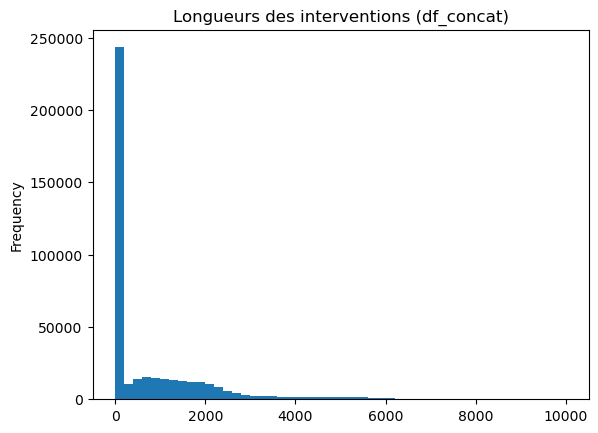

In [42]:
df_concat["texte"].str.len().plot(
    kind="hist",
    range=(0, 10000),
    bins=50,
    title="Longueurs des interventions (df_concat)",
)

<Axes: title={'center': 'Longueurs des interventions (df)'}, ylabel='Frequency'>

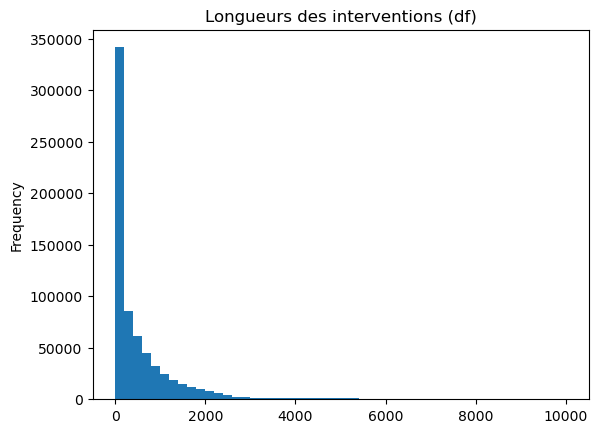

In [43]:
df["texte"].str.len().plot(
    kind="hist", range=(0, 10000), bins=50, title="Longueurs des interventions (df)"
)

exemple avant pour id_syceron 980396

Monsieur le président, nous venons de rompre avec plus de cinquante ans de pratique parlementaire : les droits de l’opposition viennent d’être bafoués comme jamais ils ne l’ont été dans cet hémicycle.

et après [980396, 980398, 980401]

Monsieur le président, nous venons de rompre avec plus de cinquante ans de pratique parlementaire : les droits de l’opposition viennent d’être bafoués comme jamais ils ne l’ont été dans cet hémicycle. La majorité choisit son opposition : cela n’était jamais arrivé ! Cette opération a été menée par sept ou huit de nos collègues, lesquels ont d’ailleurs menti et trompé les membres de leur groupe, si j’ai bien compris ce qu’il s’est passé.En choisissant trois questeurs totalement acquis au Gouvernement – ce n’est absolument pas un reproche : cela relève de leur responsabilité –, nous nous trouvons dans une situation extrêmement grave, monsieur le président : il n’y a plus de contrôle budgétaire dans cette maison ! C’est la première fois que cela arrive ! Alors même que la majorité ne cesse de parler de transparence, jamais une telle situation n’a existé !Monsieur le président, je ne sais pas comment cela évoluera, mais autant nous dire clairement que toutes les règles tombent. Le calcul par points que vous nous avez présenté n’a plus d’utilité puisque c’est la majorité qui décide de son opposition. Comprenez que les travaux de cette assemblée ne peuvent pas commencer de cette façon !Je vous demande, monsieur le président, de réunir les présidents de groupe car jamais, dans l’histoire de notre assemblée, les droits de l’opposition n’ont été piétinés comme ils viennent de l’être, sur l’initiative de sept ou huit individus qui ont menti, y compris à leur propre groupe parlementaire. (Vifs applaudissements sur plusieurs bancs.)

## Exploration

In [44]:
# aperçu des répartitions
df.groupby("code_parole", dropna=False)["len_dirtytext"].describe()

# TODO: voir à la toute fin si besoin de modifier les codes pris en compte avis_ ?

,count,mean,std,min,25%,50%,75%,max
code_parole,,,,,,,,
(null),1.0,186.000000,NaN,186.0,186.00,186.0,186.00,186.0
AVIS_COM_1_10,1.0,1278.000000,NaN,1278.0,1278.00,1278.0,1278.00,1278.0
AVIS_COM_1_20,45107.0,450.390582,482.536522,3.0,118.50,315.0,618.00,8179.0
AVIS_GVT_1_20,38454.0,486.647371,681.527170,4.0,17.00,240.0,685.00,11340.0
PAROLE_1_1,21.0,556.761905,1080.603346,30.0,101.00,241.0,529.00,5088.0
PAROLE_1_2,247778.0,974.519219,1294.330875,3.0,245.00,547.0,1207.00,68092.0
PRESIDE_DISCOURS_1_10,2.0,95.500000,92.630988,30.0,62.75,95.5,128.25,161.0
Raccroche_apres_inter,9.0,1638.666667,1450.025431,60.0,154.00,1340.0,2316.00,3939.0
non_précisé,352287.0,282.342874,625.719777,1.0,17.00,37.0,251.00,25609.0


In [45]:
# TODO: vérifier les modifs RN :
# On passe de
# RN          21684
# à
# RN         28977

# Et les NI de
# NI          12966
# à
# NI          5673

# 7293

# TODO: possible de checker contre groupeAbrev

In [46]:
# Sélectionner les députés RN selon l'affiliation
df_rn = df[df["groupe_all_affiliation"] == "RN"]

# Comparer la colonne 'groupeAbrev' pour ces députés
# utiliser ou non drop_duplicates pour éviter les doublons selon but
comparison = df_rn[
    ["id_acteur", "nom_orateur", "groupe_all_affiliation", "groupeAbrev"]
]  # .drop_duplicates()

# Afficher les différentes valeurs de groupeAbrev pour les RN
print(comparison["groupeAbrev"].value_counts())

comparison

groupeAbrev
RN    23393
NI     4918
Name: count, dtype: int64


,id_acteur,nom_orateur,groupe_all_affiliation,groupeAbrev
333,PA719608,Mme Emmanuelle Ménard,RN,NI
371,PA719608,Mme Emmanuelle Ménard,RN,NI
373,PA719608,Mme Emmanuelle Ménard,RN,NI
405,PA719608,Mme Emmanuelle Ménard,RN,NI
510,PA719608,Mme Emmanuelle Ménard,RN,NI
...,...,...,...,...
683608,PA795836,M. Frédéric Cabrolier,RN,RN
683617,PA795836,M. Frédéric Cabrolier (RN),RN,RN
683619,PA795836,M. Frédéric Cabrolier,RN,RN
683649,PA795836,M. Frédéric Cabrolier (RN),RN,RN


In [47]:
# explorer les affiliation manquantes pour identifier les cas limites
# Notamment regarder ceux qui n'ont pas d'affiliation mais bien un groupeAbrev
# Et aviser si on veut forcer l'affiliation à la derniere connue dans df_deputes
# En réalité sans doute des membres du gouvernement, donc toujours le même souci
# de décision à prendre selon l'usage qu'on veut faire des données
# -> ok avec Vincent, ça se défend sans pb.

In [48]:
df_missing_affil = df[df["groupeAbrev"].notna() & df["groupe_all_affiliation"].isna()]

In [49]:
df_missing_affil.shape

(0, 52)

In [50]:
df_missing_affil[["id_acteur", "nom_orateur", "groupeAbrev", "dateSeance_ts"]]

,id_acteur,nom_orateur,groupeAbrev,dateSeance_ts


In [51]:
df["groupe_all_affiliation"] = df["groupe_all_affiliation"].combine_first(df["groupeAbrev"])

In [52]:
df_missing_affil["id_acteur"].nunique()

0

In [53]:
df_missing_affil[
    "nom_orateur"
].unique()  # différent de nb id_acteur unique car pb d'harmonisation noms

array([], dtype=object)

In [54]:
df_missing_affil["id_acteur"].value_counts()[
    :50
]  # différent de nb id_acteur unique car pb d'harmonisation noms

Series([], Name: count, dtype: int64)

In [55]:
df_missing_affil["nom_orateur"].value_counts()[
    :50
]  # différent de nb id_acteur unique car pb d'harmonisation noms

Series([], Name: count, dtype: int64)

In [56]:
df_missing_affil["nom_orateur_clean"].value_counts()[:50]

Series([], Name: count, dtype: int64)

In [57]:
# TODO: affiner affiliation

# Avoir plusieurs variables
# une d'info gouv vs députés

# pour affiliation
# une des députés (le reste en missing) = ce que l'on a
# une des députes + membres gouv = les afficher en tant que tel comme "groupe"ArithmeticError
# une des députés + ancienne affiliation des membres gouv = compléter les missing
# TODO: matthias : check les cas particuliers.


In [58]:
df["id_acteur"].isna().sum()  # 0

np.int64(40)

In [59]:
chelou = df[df["id_acteur"].isna()]

In [60]:
chelou

,UID,SeanceRef,SessionRef,dateSeance,dateSeanceJour,numSeanceJour,numSeance,typeAssemblee,legislature,session,...,nombreMandats,experienceDepute,scoreParticipation,scoreLoyaute,scoreMajorite,dateMaj,dateSeance_ts,groupe_députés_affiliation,groupe&gvt_affiliation,groupe_all_affiliation
6073,CRSANR5L15S2017E1N004,NaN,NaN,20170706150000000,jeudi 06 juillet 2017,2,4,AN,15,Première session extraordinaire 2017,...,NaN,NaN,NaN,NaN,NaN,NaN,2017-07-06 15:00:00,None,GVT,NaN
14405,CRSANR5L15S2020O1N051,NaN,NaN,20191031150000000,jeudi 31 octobre 2019,2,51,AN,15,session ordinaire 2019-2020,...,NaN,NaN,NaN,NaN,NaN,NaN,2019-10-31 15:00:00,None,GVT,NaN
23548,CRSANR5L15S2017E1N005,NaN,NaN,20170710160000000,lundi 10 juillet 2017,1,5,AN,15,Première session extraordinaire 2017,...,NaN,NaN,NaN,NaN,NaN,NaN,2017-07-10 16:00:00,None,GVT,NaN
53648,CRSANR5L15S2019O1N146,NaN,NaN,20190213150000000,mercredi 13 février 2019,1,146,AN,15,Session ordinaire 2018-2019,...,NaN,NaN,NaN,NaN,NaN,NaN,2019-02-13 15:00:00,None,GVT,NaN
76546,CRSANR5L15S2021O1N035,NaN,NaN,20201023090000000,vendredi 23 octobre 2020,1,35,AN,15,session ordinaire 2020-2021,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-23 09:00:00,None,GVT,NaN
96546,CRSANR5L15S2019O1N021,NaN,NaN,20181017150000000,mercredi 17 octobre 2018,1,21,AN,15,Session ordinaire 2018-2019,...,NaN,NaN,NaN,NaN,NaN,NaN,2018-10-17 15:00:00,None,GVT,NaN
102007,CRSANR5L15S2021O1N156,NaN,NaN,20210208160000000,lundi 08 février 2021,1,156,AN,15,session ordinaire 2020-2021,...,NaN,NaN,NaN,NaN,NaN,NaN,2021-02-08 16:00:00,None,GVT,NaN
102008,CRSANR5L15S2021O1N156,NaN,NaN,20210208160000000,lundi 08 février 2021,1,156,AN,15,session ordinaire 2020-2021,...,NaN,NaN,NaN,NaN,NaN,NaN,2021-02-08 16:00:00,None,GVT,NaN
109045,CRSANR5L15S2021O1N220,RUANR5L15S2021IDS24032,SCR5A2021O1,20210330150000000,mardi 30 mars 2021,1,220,AN,15,session ordinaire 2020-2021,...,NaN,NaN,NaN,NaN,NaN,NaN,2021-03-30 15:00:00,None,GVT,NaN
135844,CRSANR5L15S2021O1N078,NaN,NaN,20201113210000000,vendredi 13 novembre 2020,3,78,AN,15,session ordinaire 2020-2021,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-13 21:00:00,None,GVT,NaN


- 11 n'ont pas de texte, 
- 8 sont des dydascalies entre parenthèses qui vont sauter au début du notebook 3, 
- 5 sont des fausses valeurs manquantes, 
- 3 sont des paroles de la présidence qui auraient du sauter au début du notebook mais mal identifiées dans le CRI. 
- 1 interruption
- ==> 12 qui peuvent être des prises de paroles dont 0 ne mentionnent la République, et 1 seule potentiellement l'IR "liberté d'association". 